In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.Cartpole_Control_Utils import *
import time

c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Run one episode

True length: 0.5, Model length: 0.5
Running episode with mpc controller...
Horizon: 30, dt: 0.02, recompute_every: 1
Step 10, Time 0.20s, Angle 0.0078 rad, Cart Pos 0.0531 m, Action 0, PE_theta -0.0005
Step 20, Time 0.40s, Angle 0.0148 rad, Cart Pos 0.0626 m, Action 1, PE_theta 0.0002
Step 30, Time 0.60s, Angle 0.0048 rad, Cart Pos 0.0875 m, Action 1, PE_theta -0.0000
Step 40, Time 0.80s, Angle 0.0087 rad, Cart Pos 0.1045 m, Action 1, PE_theta 0.0005
Step 50, Time 1.00s, Angle 0.0030 rad, Cart Pos 0.1291 m, Action 1, PE_theta 0.0000
Step 60, Time 1.20s, Angle -0.0017 rad, Cart Pos 0.1538 m, Action 0, PE_theta -0.0001
Step 70, Time 1.40s, Angle 0.0060 rad, Cart Pos 0.1706 m, Action 1, PE_theta 0.0005
Step 80, Time 1.60s, Angle 0.0026 rad, Cart Pos 0.1951 m, Action 1, PE_theta -0.0000
Step 90, Time 1.80s, Angle -0.0001 rad, Cart Pos 0.2197 m, Action 0, PE_theta -0.0001
Step 100, Time 2.00s, Angle 0.0100 rad, Cart Pos 0.2364 m, Action 1, PE_theta 0.0002
Step 110, Time 2.20s, Angle -0.0011

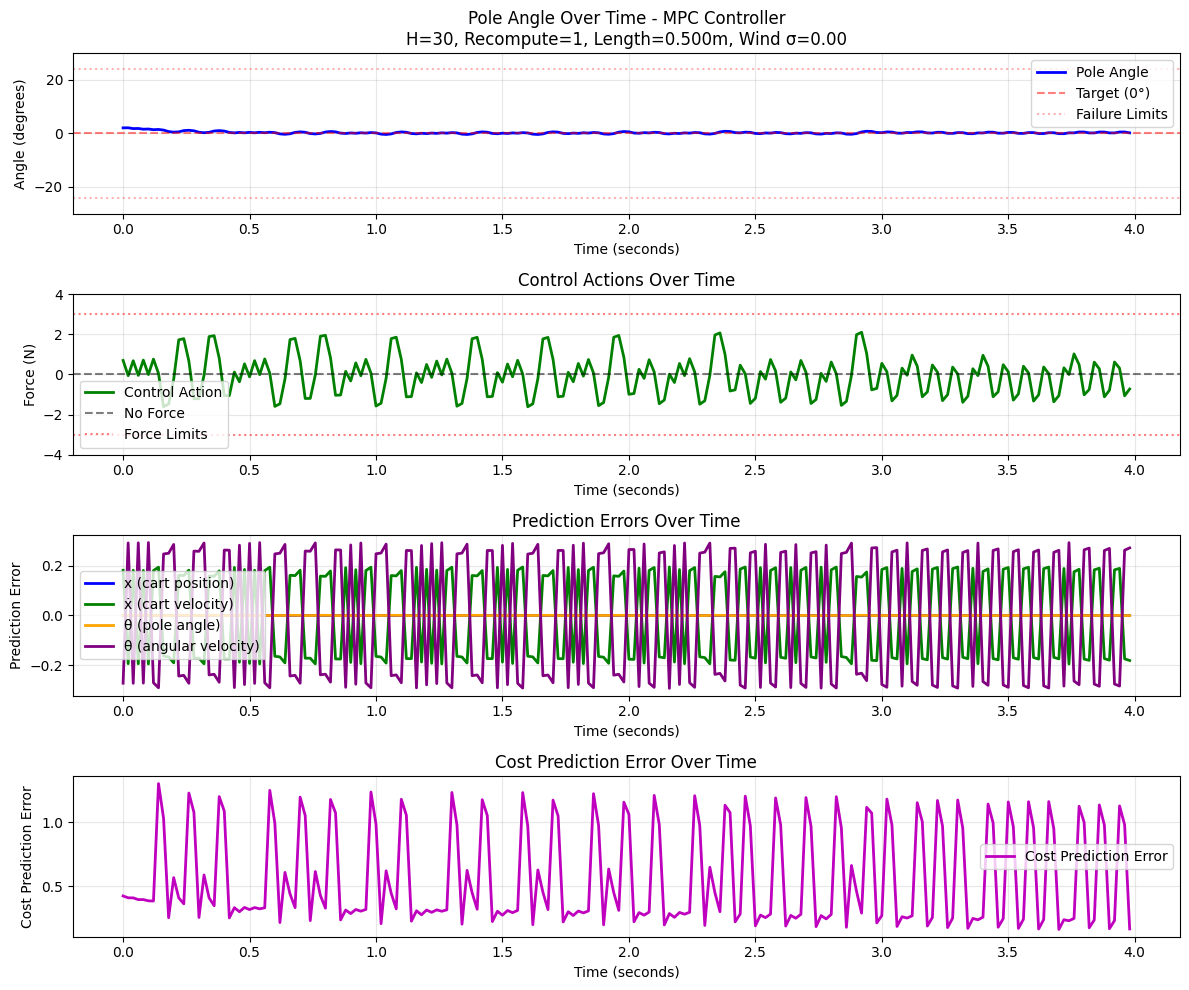


Completed 200 steps, survived 3.98 seconds
Max angle: 2.08°
Max cart position: 0.535 m


array([[-1.30522696e-04,  1.73325321e-05, -1.28427435e-04,
         1.39432293e-05, -1.35108564e-04,  5.26646858e-06,
        -1.45140560e-04, -5.74712768e-06,  3.16573678e-04,
         2.90318388e-04,  4.86837588e-05, -3.34260000e-04,
        -3.45188862e-04, -1.27612630e-04,  2.38720263e-04,
         2.36963297e-04,  8.71564054e-06, -3.66408571e-04,
        -3.74418736e-04, -1.55926956e-04,  2.10085853e-04,
         2.07231197e-04, -2.26477135e-05,  7.29387354e-05,
        -1.01896894e-04,  2.46678796e-05, -1.32851634e-04,
         3.23310038e-06, -1.49218917e-04, -1.06310565e-05,
         3.11608992e-04,  2.85500660e-04,  4.42244902e-05,
        -3.38578625e-04, -3.49221846e-04, -1.31474780e-04,
         2.34929434e-04,  2.33130368e-04,  4.75963426e-06,
        -3.70786019e-04, -3.79165650e-04, -1.61188097e-04,
         2.04145811e-04,  2.00509189e-04, -3.03071514e-05,
         6.41908750e-05, -1.11891088e-04,  1.32721057e-05,
        -1.45826037e-04, -1.14952724e-05,  3.07719618e-0

In [2]:
# Run one episode
run_single_episode_with_plots(
    controller_type='mpc', 
    horizon=30,            
    dt=0.02, 
    recompute_every=1, 
    model_length=1.0,      
    wind_mu=0.0, 
    wind_sigma=0.0,        
    episode_length=200,    
    seed=42
)

## Train and evaluate the models

In [ ]:
# Create 'Results' folder if it doesn't exist
results_folder = "../results/PerformanceResults/"

# Make sure the folders exist
for folder in [results_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Lists for timing results
results_records = []

#------------------------------------------------------------------------------------------------------------------------------------------------
# Train/evaluate the MPC model
#------------------------------------------------------------------------------------------------------------------------------------------------
start_time = time.time()
mpc_results = evaluate_mpc_controllers(
        controller='predictive',
        horizons=[10, 30, 50, 70, 90, 110],
        recompute_intervals=[1,2,3,4,5],
        dt = 0.02,
        length_ratios=[1.0, 2.0, 3.0, 4.0],
        wind_mus=[0.0], 
        wind_sigmas=[0.0, 0.05, 0.1, 0.15],
        results_folder="../results/PerformanceResults/",
        episode_length=500,
        num_episodes=1,
        init_angles=[0.0]    )

## Pole length error

Found data for horizons: [10, 30, 50, 70, 90, 110] steps = ['0.2s', '0.6s', '1.0s', '1.4s', '1.8s', '2.2s']
Found data for recompute intervals: [1, 2, 3, 4, 5] steps = ['0.02s', '0.04s', '0.06s', '0.08s', '0.10s']
Plotting ratios: [1.0, 2.0, 3.0, 4.0]

Plot saved to: ../results/PerformanceResults/mpc_4d_performance_heatmaps_wmu0.0_wsig0.0_iang0.00.png


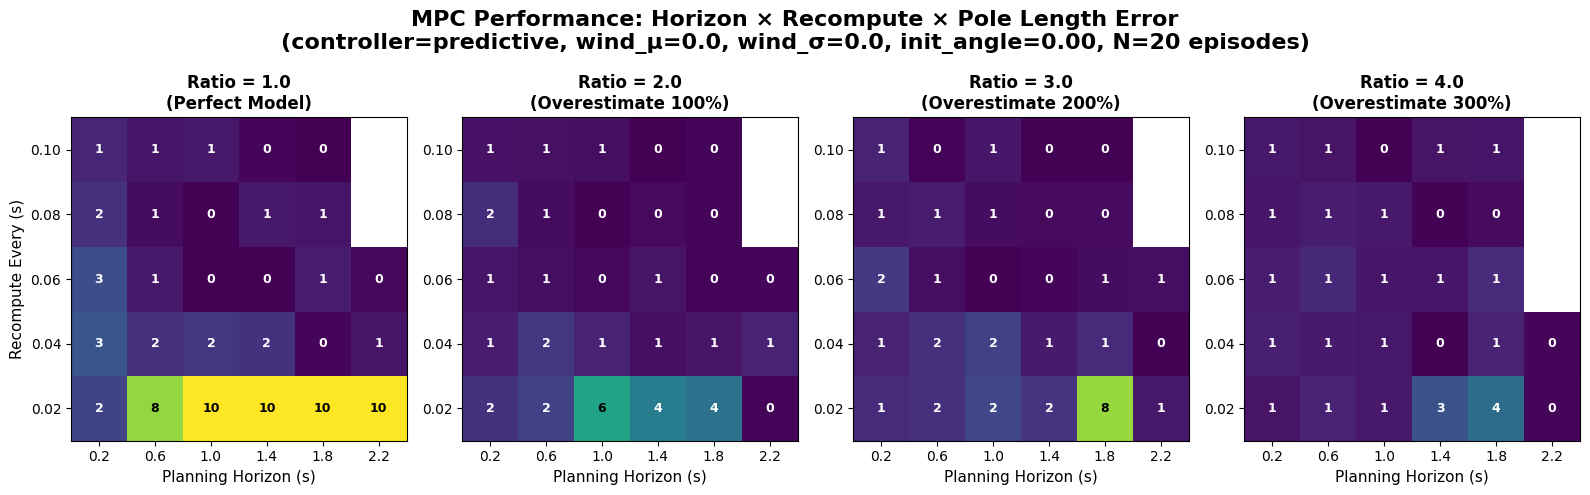

In [8]:
plot_pole_angle_heatmaps(results_folder="../results/PerformanceResults/", 
                                controller='predictive',
                                length_ratios=[1.0, 2.0, 3.0, 4.0],
                                wind_mu=0.0,
                                wind_sigma=0.0,
                                init_angle=0.0)

## Wind sigma error

Found data for horizons: [5, 10, 20, 30] steps = ['0.1s', '0.2s', '0.4s', '0.6s']
Found data for recompute intervals: [1, 2, 3] steps = ['0.02s', '0.04s', '0.06s']
Plotting wind std devs: [0.0, 0.05, 0.1]

Plot saved to: ../results/PerformanceResults/mpc_wind_sigma_heatmaps_r1.0_m0.0_iang0.00.png


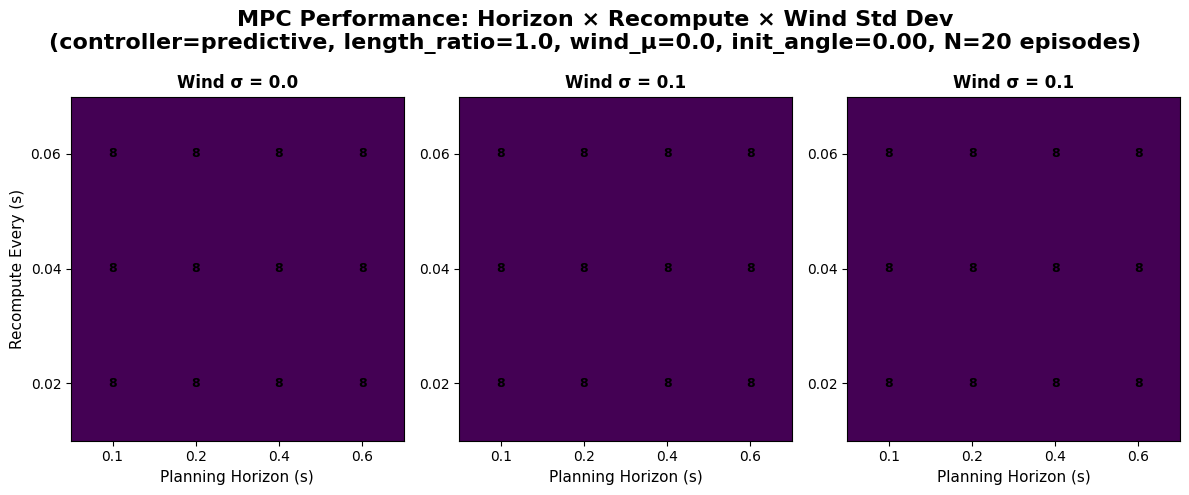

In [10]:
plot_wind_sigma_heatmaps(
    results_folder="../results/PerformanceResults/",
    controller='predictive',
    wind_sigmas=[0.0, 0.05, 0.1],
    length_ratio=1.0,
    wind_mu=0.0,
    init_angle=0.0

)

## Wind error

In [ ]:
plot_wind_mu_heatmaps(
    controller='mpc',
    results_folder="../results/PerformanceResults/",
    wind_mus=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_sigma=0.0,
    init_angle=0.0,
)

No data found for ratio=1.0, sigma=0.0, init_angle=0.0


## Initialization angle

Found data for horizons: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
Found data for recompute intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Plotting initial angles: [0.0, 0.05, 0.1, 0.15]

Plot saved to: ../results/PerformanceResults/mpc_init_angle_heatmaps_r1.0_m0.0_s0.0_ascontinuous.png


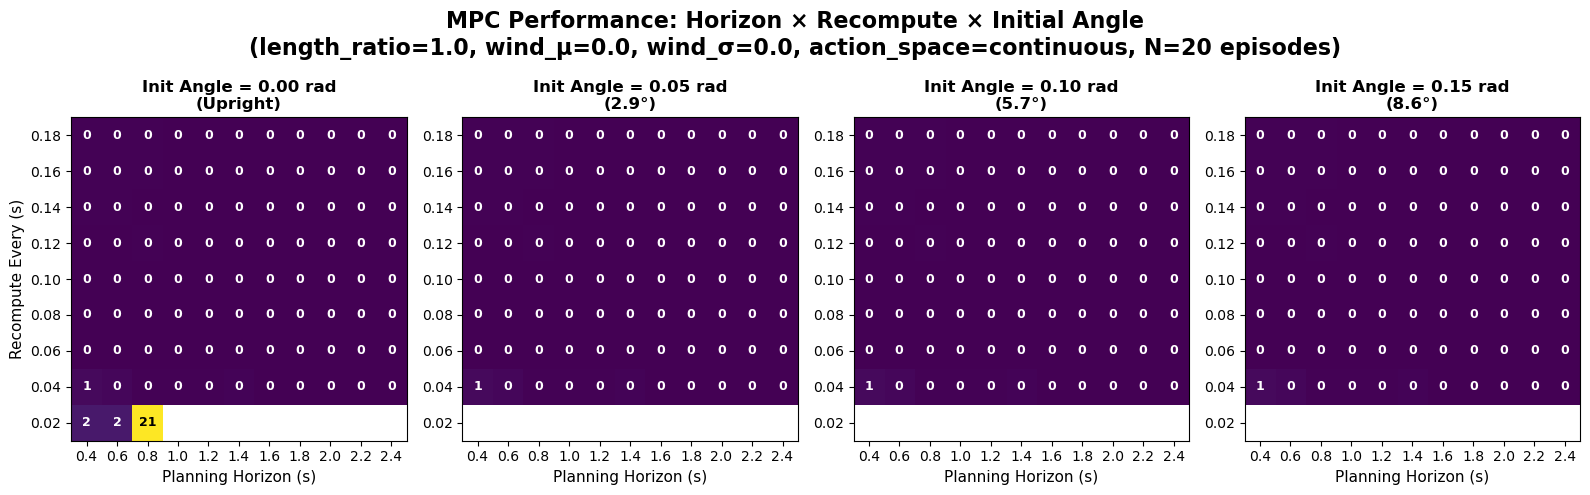

In [ ]:
# Create heatmaps for different initial angles
plot_init_angle_heatmaps(
    controller='mpc',
    init_angles=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_mu=0.0,
    wind_sigma=0.0,
    action_space='continuous',
)